# 18 — Apply Basel risk weights

Convert net sensitivities into weighted sensitivities using regulatory parameters.

A risk weight (RW) belongs to a regulatory risk factor, bucket or tenor rather than simply to an instrument. One bond can therefore receive different GIRR, CSR and FX weights on its separate risk rows. Synthetic market data generate sensitivity; Basel configuration supplies the weight.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

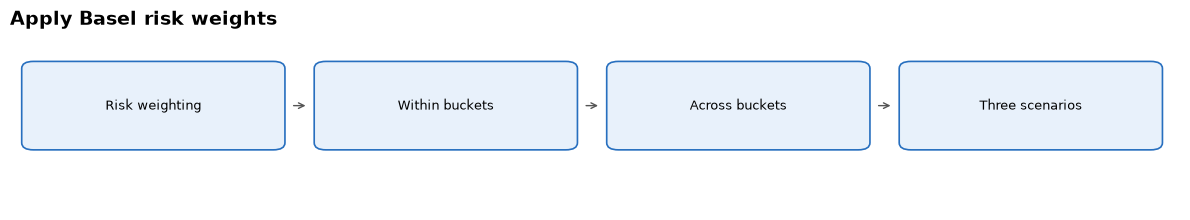

In [2]:
draw_flow(['Risk weighting', 'Within buckets', 'Across buckets', 'Three scenarios'],'Apply Basel risk weights',wrap_after=4)

First review the complete delta and vega schedules. Then multiply each exact-factor net sensitivity by its applicable weight. Curvature is different: the delta risk weight defines the up and down revaluation shock and is not multiplied a second time.

$$WS_k=RW_k\times s_k$$

In [3]:
from frtb_engine.config import load_sbm_parameters
params=load_sbm_parameters(); delta_rw=params['delta_risk_weights']; schedules=[]
girr_rows=[{'risk_class':'GIRR','factor_or_bucket':f'{tenor:g}Y tenor','risk_weight':weight} for tenor,weight in delta_rw['GIRR']['tenors'].items()]
girr_rows += [{'risk_class':'GIRR','factor_or_bucket':'Inflation — flat factor','risk_weight':delta_rw['GIRR']['inflation']},
              {'risk_class':'GIRR','factor_or_bucket':'Cross-currency basis — flat factor','risk_weight':delta_rw['GIRR']['cross_currency_basis']}]
schedules.extend(girr_rows)
for risk_class in ['CSR_NON_SECURITISATION','CSR_SECURITISATION_CTP']:
    schedules.extend({'risk_class':risk_class,'factor_or_bucket':f'Bucket {bucket}','risk_weight':weight}
                     for bucket,weight in delta_rw[risk_class]['buckets'].items())
nonctp=delta_rw['CSR_SECURITISATION_NON_CTP']
for bucket,base in nonctp['base_buckets_1_to_8'].items():
    schedules.append({'risk_class':'CSR_SECURITISATION_NON_CTP','factor_or_bucket':f'Bucket {bucket} — senior IG','risk_weight':base})
    schedules.append({'risk_class':'CSR_SECURITISATION_NON_CTP','factor_or_bucket':f'Bucket {bucket+8} — non-senior IG','risk_weight':base*nonctp['non_senior_ig_multiplier']})
    schedules.append({'risk_class':'CSR_SECURITISATION_NON_CTP','factor_or_bucket':f'Bucket {bucket+16} — high yield','risk_weight':base*nonctp['high_yield_multiplier']})
schedules.append({'risk_class':'CSR_SECURITISATION_NON_CTP','factor_or_bucket':'Bucket 25 — other','risk_weight':nonctp['other_bucket_25']})
for risk_class,key in [('EQUITY','spot_buckets'),('COMMODITY','buckets')]:
    schedules.extend({'risk_class':risk_class,'factor_or_bucket':f'Bucket {bucket}','risk_weight':weight}
                     for bucket,weight in delta_rw[risk_class][key].items())
schedules.append({'risk_class':'FX','factor_or_bucket':'All currency pairs','risk_weight':delta_rw['FX']['all_pairs']})
delta_schedule=pd.DataFrame(schedules)
print('Complete delta risk-weight schedule')
for risk_class,data in delta_schedule.groupby('risk_class',sort=False):
    print(risk_class.replace('_',' ')); display(percent_columns(data[['factor_or_bucket','risk_weight']],['risk_weight']))
vega_schedule=pd.DataFrame([{'risk_class':key.replace('_',' '),'risk_weight':value}
                            for key,value in params['vega_risk_weights'].items() if key!='source'])
print('Complete vega risk-weight schedule')
display(percent_columns(vega_schedule,['risk_weight']))

weighted=pd.concat([pd.read_csv(RUN/'06_delta_netted_weighted.csv'),pd.read_csv(RUN/'07_vega_netted_weighted.csv')],ignore_index=True)
weighted['calculated_weighted']=weighted.raw_sensitivity*weighted.risk_weight
columns=['risk_measure','risk_class','bucket','risk_factor_id','raw_sensitivity','risk_weight','weighted_sensitivity']
shown=crore_table(weighted[columns],['raw_sensitivity','weighted_sensitivity'])
display_sample(percent_columns(shown,['risk_weight']),30)
example=weighted.iloc[0]
print(f"Worked factor {example.risk_factor_id}: {example.raw_sensitivity:,.2f} x {example.risk_weight*100:,.2f}% = {example.weighted_sensitivity:,.2f}")

Complete delta risk-weight schedule
GIRR


,factor_or_bucket,Risk Weight (%)
0,0.25Y tenor,1.7000
1,0.5Y tenor,1.7000
2,1Y tenor,1.6000
3,2Y tenor,1.3000
4,3Y tenor,1.2000
5,5Y tenor,1.1000
6,10Y tenor,1.1000
7,15Y tenor,1.1000
8,20Y tenor,1.1000
9,30Y tenor,1.1000


CSR NON SECURITISATION


,factor_or_bucket,Risk Weight (%)
12,Bucket 1,0.5000
13,Bucket 2,1.0000
14,Bucket 3,5.0000
15,Bucket 4,3.0000
16,Bucket 5,3.0000
17,Bucket 6,2.0000
18,Bucket 7,1.5000
19,Bucket 8,2.5000
20,Bucket 9,2.0000
21,Bucket 10,4.0000


CSR SECURITISATION CTP


...

Complete vega risk-weight schedule


,risk_class,Risk Weight (%)
0,GIRR,100.0000
1,CSR NON SECURITISATION,100.0000
2,CSR SECURITISATION NON CTP,100.0000
3,CSR SECURITISATION CTP,100.0000
4,EQUITY LARGE AND INDEX,77.7800
5,EQUITY SMALL AND OTHER,100.0000
6,COMMODITY,100.0000
7,FX,100.0000


Displayed rows: first 30 of 59 observations, in table order.


,risk_measure,risk_class,bucket,risk_factor_id,Raw Sensitivity (INR crore per unit change),Risk Weight (%),Weighted Sensitivity (INR crore)
0,DELTA,COMMODITY,2,BRENT_0.25Y_GLOBAL,72.4080,35.0000,25.3428
1,DELTA,COMMODITY,2,BRENT_0.5Y_GLOBAL,22.8589,35.0000,8.0006
2,DELTA,COMMODITY,2,BRENT_1.0Y_GLOBAL,-57.9264,35.0000,-20.2742
3,DELTA,COMMODITY,2,WTI_0.5Y_GLOBAL,48.2720,35.0000,16.8952
4,DELTA,COMMODITY,7,GOLD_0.25Y_GLOBAL,41.0312,20.0000,8.2062
5,DELTA,COMMODITY,7,GOLD_1.0Y_GLOBAL,-25.2470,20.0000,-5.0494
6,DELTA,CSR_NON_SECURITISATION,12,INDIA_METALS_3.0Y,-11.7923,7.0000,-0.8255
7,DELTA,CSR_NON_SECURITISATION,12,INDIA_METALS_5.0Y,-11.7923,7.0000,-0.8255
8,DELTA,CSR_NON_SECURITISATION,3,AXIS_BANK_5.0Y,-21.9323,5.0000,-1.0966
9,DELTA,CSR_NON_SECURITISATION,4,US_INDUSTRIAL_10.0Y,-29.7755,3.0000,-0.8933


Worked factor BRENT_0.25Y_GLOBAL: 724,080,000.00 x 35.00% = 253,428,000.00


The visual below uses the calculated rows shown above.

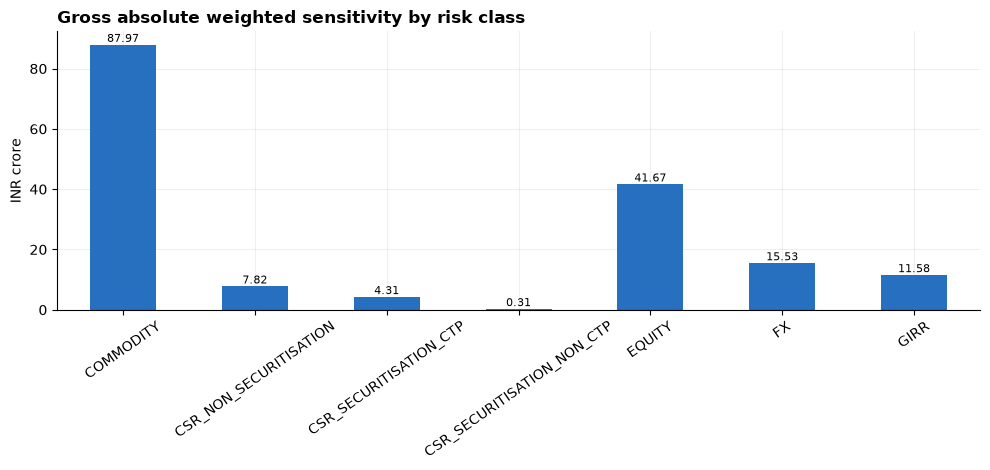

In [4]:
bar_crore(weighted.groupby('risk_class')['weighted_sensitivity'].apply(lambda x:x.abs().sum()),'Gross absolute weighted sensitivity by risk class')

Weighted sensitivities can now be combined using prescribed correlations.